# Tabular Kaggle Classification Project

Binary classification on an anonymous financial dataset.

| Property | Value |
|---|---|
| Rows | ~70,000 |
| Raw features | 370 |
| Target | Binary (0 / 1) — heavily imbalanced (~0.4% positive) |

**Pipeline overview:**
1. Data Loading & Initial Inspection
2. Preprocessing (normalize, drop useless columns, variance filtering)
3. EDA (distributions, correlations)
4. Machine Learning (Random Forest, feature importance, model pruning)

In [68]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 1. Data Loading & Initial Inspection

Load the training CSV, drop the non-predictive `ID` column, and do a quick sanity check:
- Column names and data types
- Missing values
- Dataset shape
- Target class distribution

In [69]:
df = pd.read_csv(r"../Dataset/train.csv")

In [70]:
#lets get all column names 
print(df.columns)


Index(['ID', 'var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1',
       'imp_op_var39_comer_ult3', 'imp_op_var40_comer_ult1',
       'imp_op_var40_comer_ult3', 'imp_op_var40_efect_ult1',
       'imp_op_var40_efect_ult3',
       ...
       'saldo_medio_var33_hace2', 'saldo_medio_var33_hace3',
       'saldo_medio_var33_ult1', 'saldo_medio_var33_ult3',
       'saldo_medio_var44_hace2', 'saldo_medio_var44_hace3',
       'saldo_medio_var44_ult1', 'saldo_medio_var44_ult3', 'var38', 'TARGET'],
      dtype='str', length=371)


In [71]:
df.head(10)

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0
5,13,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87975.750000,0
6,14,2,27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94956.660000,0
7,18,2,26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,251638.950000,0
8,20,2,45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101962.020000,0
9,23,2,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,356463.060000,0


In [72]:
df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [73]:
#since this is our training data we dont need our ID column so we can drop it
df = df.drop(columns=["ID"])

In [74]:
#check for missing values
print(df.isnull().sum())


var3                       0
var15                      0
imp_ent_var16_ult1         0
imp_op_var39_comer_ult1    0
imp_op_var39_comer_ult3    0
                          ..
saldo_medio_var44_hace3    0
saldo_medio_var44_ult1     0
saldo_medio_var44_ult3     0
var38                      0
TARGET                     0
Length: 370, dtype: int64


In [75]:
#check unique data types
print(df.dtypes)

var3                         int64
var15                        int64
imp_ent_var16_ult1         float64
imp_op_var39_comer_ult1    float64
imp_op_var39_comer_ult3    float64
                            ...   
saldo_medio_var44_hace3    float64
saldo_medio_var44_ult1     float64
saldo_medio_var44_ult3     float64
var38                      float64
TARGET                       int64
Length: 370, dtype: object


In [76]:
df.shape
#lots of features and entries

(76020, 370)

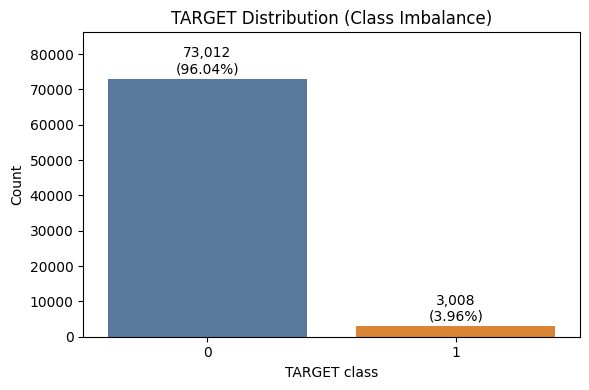

Class split:
TARGET=0: 73,012 rows (96.04%)
TARGET=1: 3,008 rows (3.96%)


In [77]:
# TARGET distribution (class imbalance) - put this early to guide modeling choices
if "TARGET" not in df.columns:
    raise KeyError("TARGET column not found in df")

target_counts = df["TARGET"].value_counts().sort_index()  # 0 then 1
n_total = target_counts.sum()
target_pct = (target_counts / n_total * 100).round(2)

plot_df = pd.DataFrame({
    "TARGET class": target_counts.index.astype(str),
    "Count": target_counts.values,
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=plot_df,
    x="TARGET class",
    y="Count",
    hue="TARGET class",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)

label_offset = n_total * 0.008
for i, v in enumerate(target_counts.values):
    ax.text(i, v + label_offset, f"{v:,}\n({target_pct.iloc[i]}%)", ha="center", va="bottom")

ax.set_ylim(0, target_counts.max() * 1.18)
plt.title("TARGET Distribution (Class Imbalance)")
plt.xlabel("TARGET class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Class split:")
for cls in target_counts.index:
    print(f"TARGET={cls}: {target_counts.loc[cls]:,} rows ({target_pct.loc[cls]}%)")

# First look thoughts
Dataset has no missing values

dataset has anonymous variable names

huge imbalance in target variable (0.4% positive class)

70000+ rows, 374 columns


# EDA
## we dont know what any of this data means so we will just do some basic EDA to see if we can find any patterns in the data

In [78]:
# find integer columns (excludes TARGET which is also int but we want features only)
int_cols = df.select_dtypes(include=["int64"]).columns.difference(["TARGET"])
print(int_cols)

Index(['delta_imp_amort_var18_1y3', 'delta_imp_amort_var34_1y3',
       'delta_imp_reemb_var13_1y3', 'delta_imp_reemb_var17_1y3',
       'delta_imp_reemb_var33_1y3', 'delta_imp_trasp_var17_in_1y3',
       'delta_imp_trasp_var17_out_1y3', 'delta_imp_trasp_var33_in_1y3',
       'delta_imp_trasp_var33_out_1y3', 'delta_num_reemb_var13_1y3',
       ...
       'saldo_var27', 'saldo_var28', 'saldo_var2_ult1', 'saldo_var34',
       'saldo_var41', 'saldo_var46', 'var15', 'var21', 'var3', 'var36'],
      dtype='str', length=258)


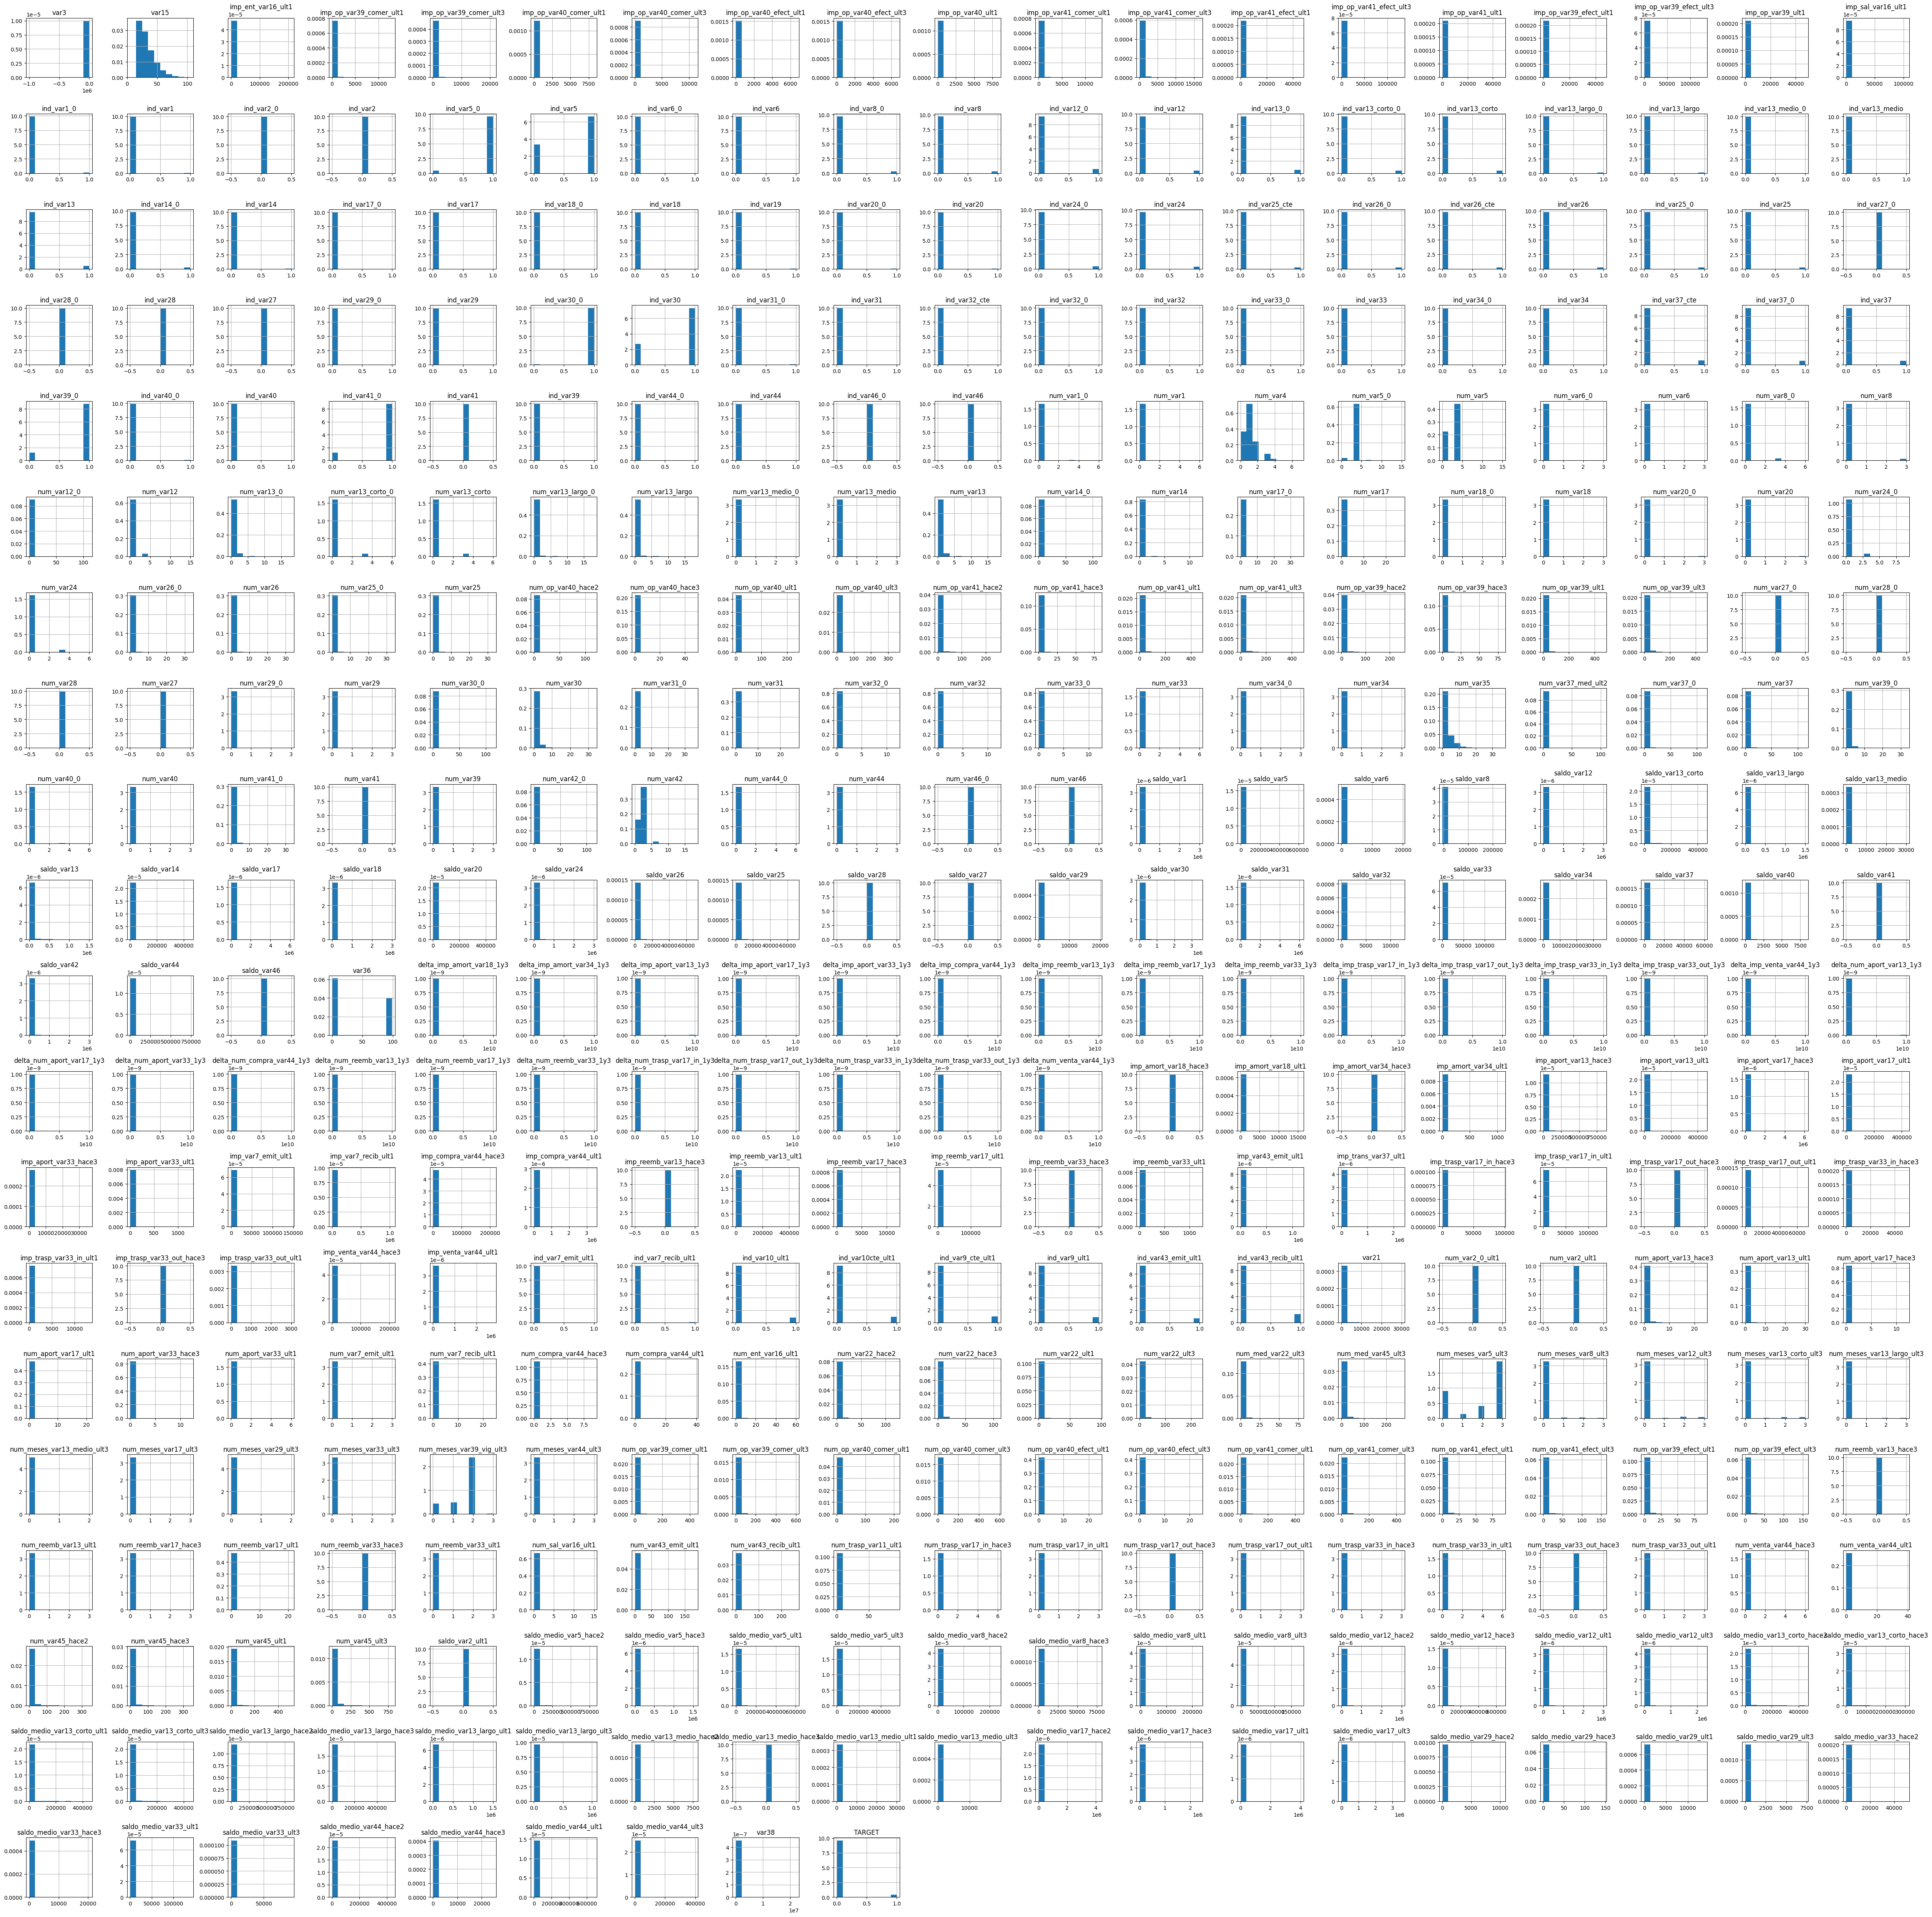

In [79]:
# lets create a histogram matrix for each of our features
df.hist(figsize=(50, 50), bins=10,density=True)
plt.tight_layout()
plt.show()

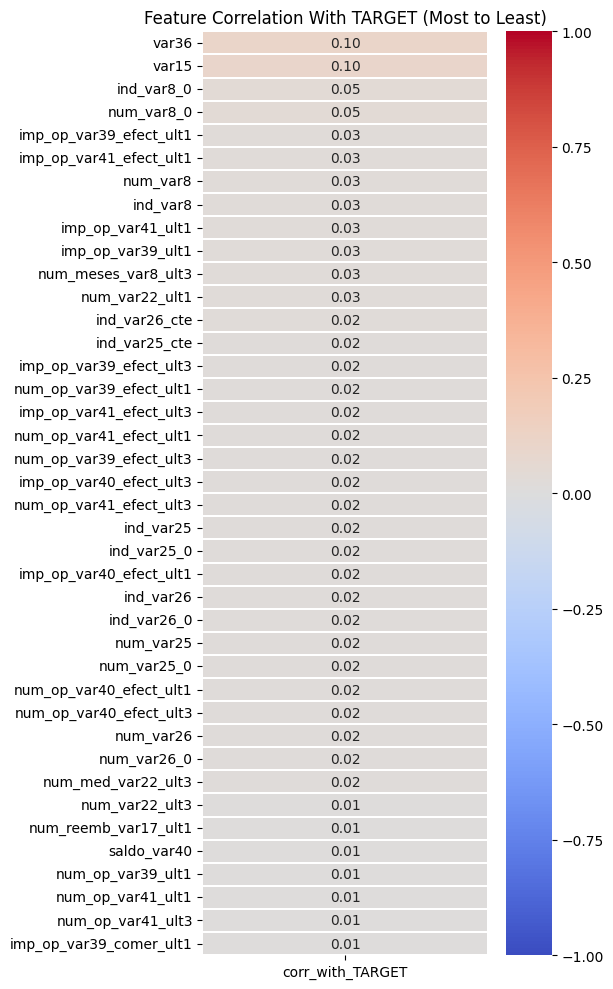

In [80]:
# Correlation of each numeric feature with TARGET only
if "TARGET" not in df.columns:
    raise KeyError("TARGET column not found in df")

num_df = df.select_dtypes(include=[np.number])
target_corr = (
    num_df.corr()["TARGET"]
    .drop("TARGET")
    .sort_values(ascending=False)
)

# Keep top correlations for readability (set to None to show all)
top_n = 40
plot_corr = target_corr.head(top_n) if top_n is not None else target_corr
heatmap_data = plot_corr.to_frame(name="corr_with_TARGET")

plt.figure(figsize=(6, max(8, len(heatmap_data) * 0.25)))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
)
plt.title("Feature Correlation With TARGET (Most to Least)")
plt.tight_layout()
plt.show()

# Thoughts on correlation

Not a a lot of strong correlation with our target variable, with the highest being a .10 correlation. This may suggest that the features are likely not linearly related to the target. A regression model would struggle here but luckily for us we are doing classification and can capture non-linear relationships. We will likely need to rely on a more complex model to capture the signal in the data, such as a random forest or gradient boosting machine.

# General thoughs
### we dont know what anu of these variables are and a lot of the columns are empty. since the whole column is empty we will just drop it.

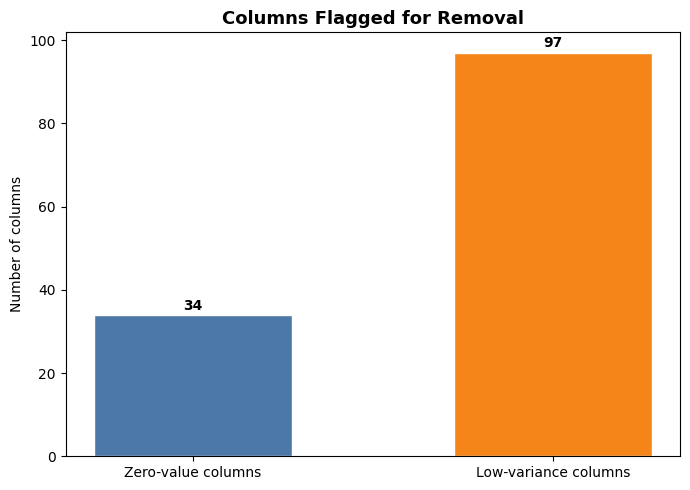

Zero-value columns: 34
Low-variance columns (threshold=0.01): 97


In [81]:
_zero_cols = [col for col in df.columns if (df[col] == 0).all()]

_selector = VarianceThreshold(threshold=0.01)
_selector.fit(df)
_low_var_cols = df.columns[~_selector.get_support()].tolist()

categories = ["Zero-value columns", "Low-variance columns"]
counts = [len(_zero_cols), len(_low_var_cols)]
colors = ["#4C78A8", "#F58518"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, counts, color=colors, edgecolor="white", width=0.55)

for bar, count in zip(bars, counts):
    ax.text(
    bar.get_x() + bar.get_width() / 2,
    bar.get_height() + 0.5,
    f"{count}",
    ha="center",
    va="bottom",
    fontweight="bold"
    )

ax.set_title("Columns Flagged for Removal", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of columns")
plt.tight_layout()
plt.show()

print(f"Zero-value columns: {len(_zero_cols)}")
print(f"Low-variance columns (threshold=0.01): {len(_low_var_cols)}")

In [82]:
# find columns where every single value is 0 (not just sum == 0, which would also
# catch columns where positive and negative values cancel out)
zero_cols = [col for col in df.columns if (df[col] == 0).all()]
print(len(zero_cols), "columns are entirely zero:", zero_cols)

34 columns are entirely zero: ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0', 'num_var28_0', 'num_var28', 'num_var27', 'num_var41', 'num_var46_0', 'num_var46', 'saldo_var28', 'saldo_var27', 'saldo_var41', 'saldo_var46', 'imp_amort_var18_hace3', 'imp_amort_var34_hace3', 'imp_reemb_var13_hace3', 'imp_reemb_var33_hace3', 'imp_trasp_var17_out_hace3', 'imp_trasp_var33_out_hace3', 'num_var2_0_ult1', 'num_var2_ult1', 'num_reemb_var13_hace3', 'num_reemb_var33_hace3', 'num_trasp_var17_out_hace3', 'num_trasp_var33_out_hace3', 'saldo_var2_ult1', 'saldo_medio_var13_medio_hace3']


In [83]:
for col in zero_cols:
    print(col)

ind_var2_0
ind_var2
ind_var27_0
ind_var28_0
ind_var28
ind_var27
ind_var41
ind_var46_0
ind_var46
num_var27_0
num_var28_0
num_var28
num_var27
num_var41
num_var46_0
num_var46
saldo_var28
saldo_var27
saldo_var41
saldo_var46
imp_amort_var18_hace3
imp_amort_var34_hace3
imp_reemb_var13_hace3
imp_reemb_var33_hace3
imp_trasp_var17_out_hace3
imp_trasp_var33_out_hace3
num_var2_0_ult1
num_var2_ult1
num_reemb_var13_hace3
num_reemb_var33_hace3
num_trasp_var17_out_hace3
num_trasp_var33_out_hace3
saldo_var2_ult1
saldo_medio_var13_medio_hace3


In [84]:
#lets verify that these columns are all by suming up the columns and making sure theyre all 0
for col in zero_cols:
    print(df[col].sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [85]:
#okay now that is confirmed lets drop all these columns
df = df.drop(columns=zero_cols)

In [86]:
#now how many columns do we have left
print(len(df.columns))

336


# Effect:
we removed 34 columns going from 370 to 336 columns. this is a good thing because it will make our model more efficient and it will also make it easier to interpret the results of our model. we also know that these columns are not important because they have no variance and they have no correlation with the target variable.

What's next is there are still plenty of columns with such little data so what do we do? 

What we are going to do is figure out what the data is telling us. we are going to meaningfuly graph the data to see if we can find any patterns in the data. we are going to look at the distribution of the data and see if there are any outliers in the data. we are also going to look at the correlation between the columns and see if there are any columns that are highly correlated with each other. we are also going to look at the correlation between the columns and the target variable to see if there are any columns that are highly correlated with the target variable.


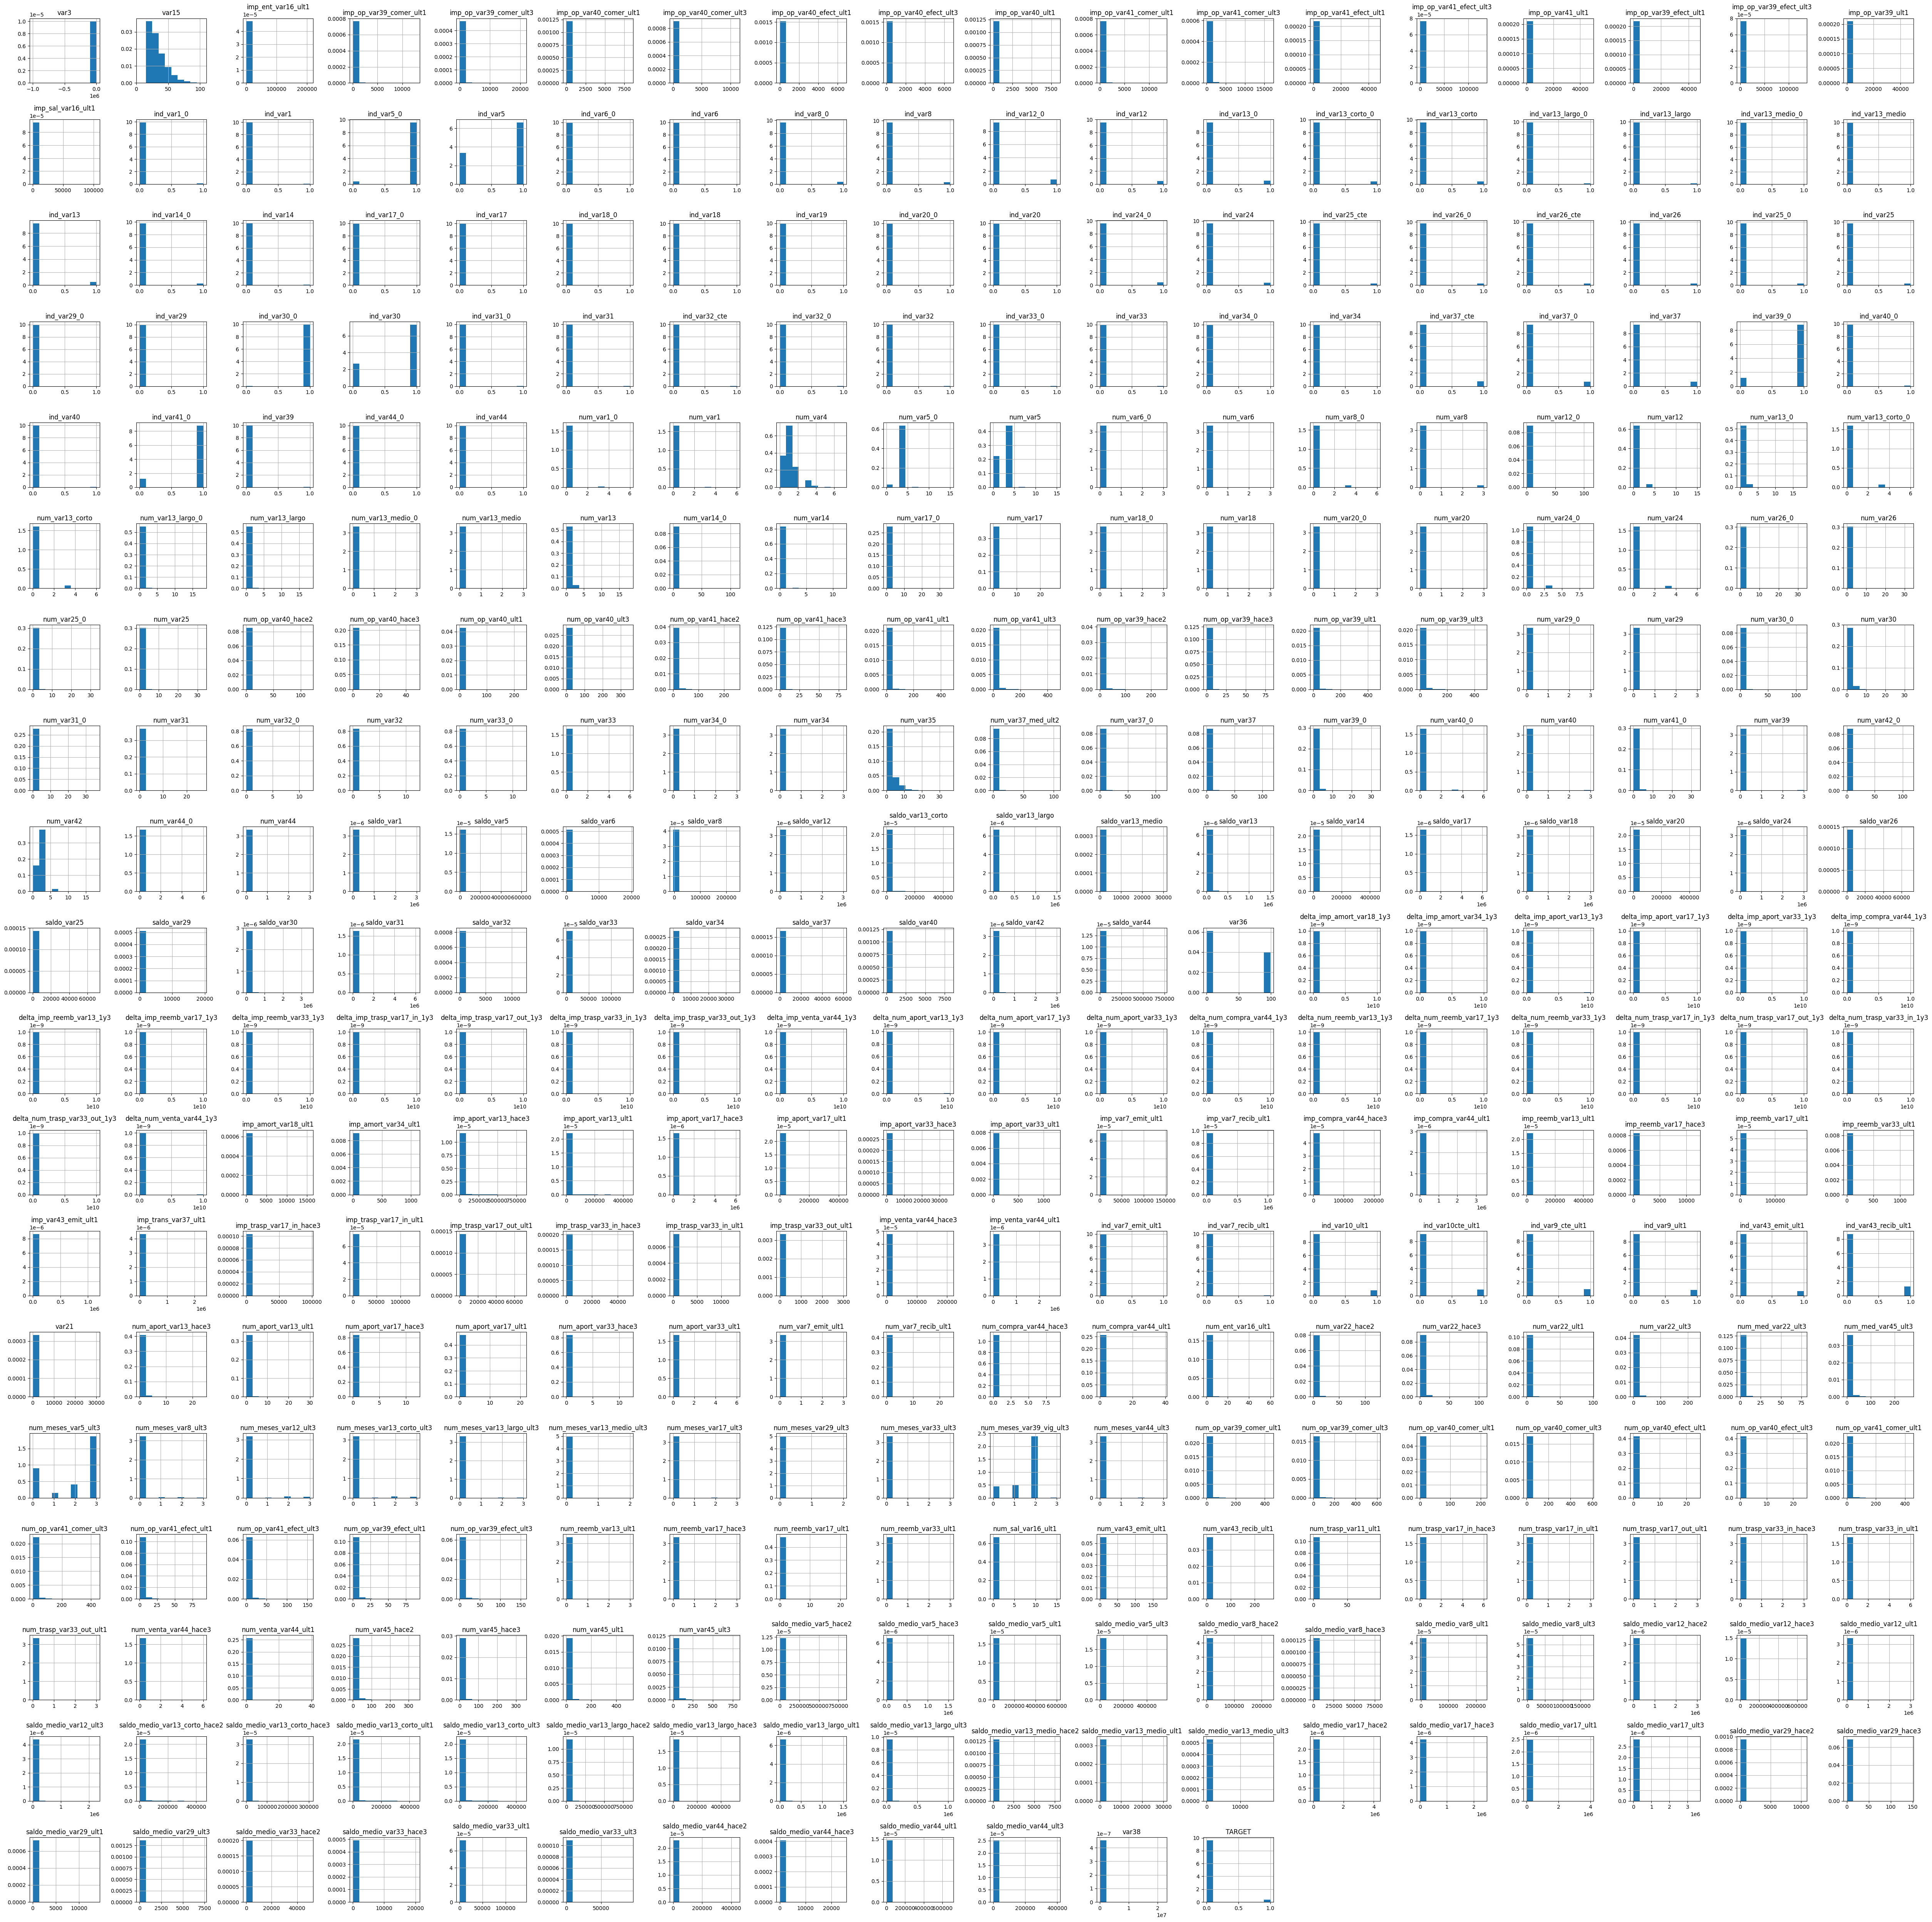

In [87]:
#lets graph the distributions of each of the columns to see if there are any patterns in the data. we will do this in a 8x8 grid so we can see all the columns at once. we will also add a title to each graph so we know which column we are looking at.

df.hist(figsize=(50, 50), bins=10,density=True)
plt.tight_layout()
plt.show()


# What now?

So this isnt working because there are stll hundreds of columns with very little data in them and going through them one-by-one is not going to be efficient.

After some research I found that these columns are known as "sparse columns" or "near zero-variance columns".

with that in mind we will move forward using scikitlearn to remove these columns for us with their nearzero variance function. this will remove any columns that have a variance of 0 or close to 0. this will help us remove any columns that have very little data in them and it will also help us remove any columns that are not important for our model.

In [88]:
#we will use variancethreshold to remove any columns that have a variance of 0 or close to 0. this will help us remove any columns that have very little data in them and it will also help us remove any columns that are not important for our model.


selector = VarianceThreshold(threshold=0.01)
selector.fit_transform(df)
#lets get the columns that were removed
removed_cols = df.columns[~selector.get_support()]
print(removed_cols)
print(len(removed_cols), "columns removed due to low variance:", removed_cols.tolist())

Index(['ind_var1', 'ind_var6_0', 'ind_var6', 'ind_var13_largo',
       'ind_var13_medio_0', 'ind_var13_medio', 'ind_var14', 'ind_var17_0',
       'ind_var17', 'ind_var18_0', 'ind_var18', 'ind_var19', 'ind_var20_0',
       'ind_var20', 'ind_var29_0', 'ind_var29', 'ind_var30_0', 'ind_var31_0',
       'ind_var31', 'ind_var32_cte', 'ind_var32_0', 'ind_var32', 'ind_var33_0',
       'ind_var33', 'ind_var34_0', 'ind_var34', 'ind_var40', 'ind_var39',
       'ind_var44_0', 'ind_var44', 'num_var6_0', 'num_var6',
       'num_var13_medio_0', 'num_var13_medio', 'num_var18_0', 'num_var18',
       'num_var29_0', 'num_var29', 'num_var33', 'num_var34_0', 'num_var34',
       'ind_var7_emit_ult1', 'ind_var7_recib_ult1', 'num_aport_var33_hace3',
       'num_aport_var33_ult1', 'num_var7_emit_ult1', 'num_compra_var44_hace3',
       'num_meses_var13_medio_ult3', 'num_meses_var17_ult3',
       'num_meses_var29_ult3', 'num_meses_var33_ult3', 'num_meses_var44_ult3',
       'num_reemb_var13_ult1', 'num_reemb_var

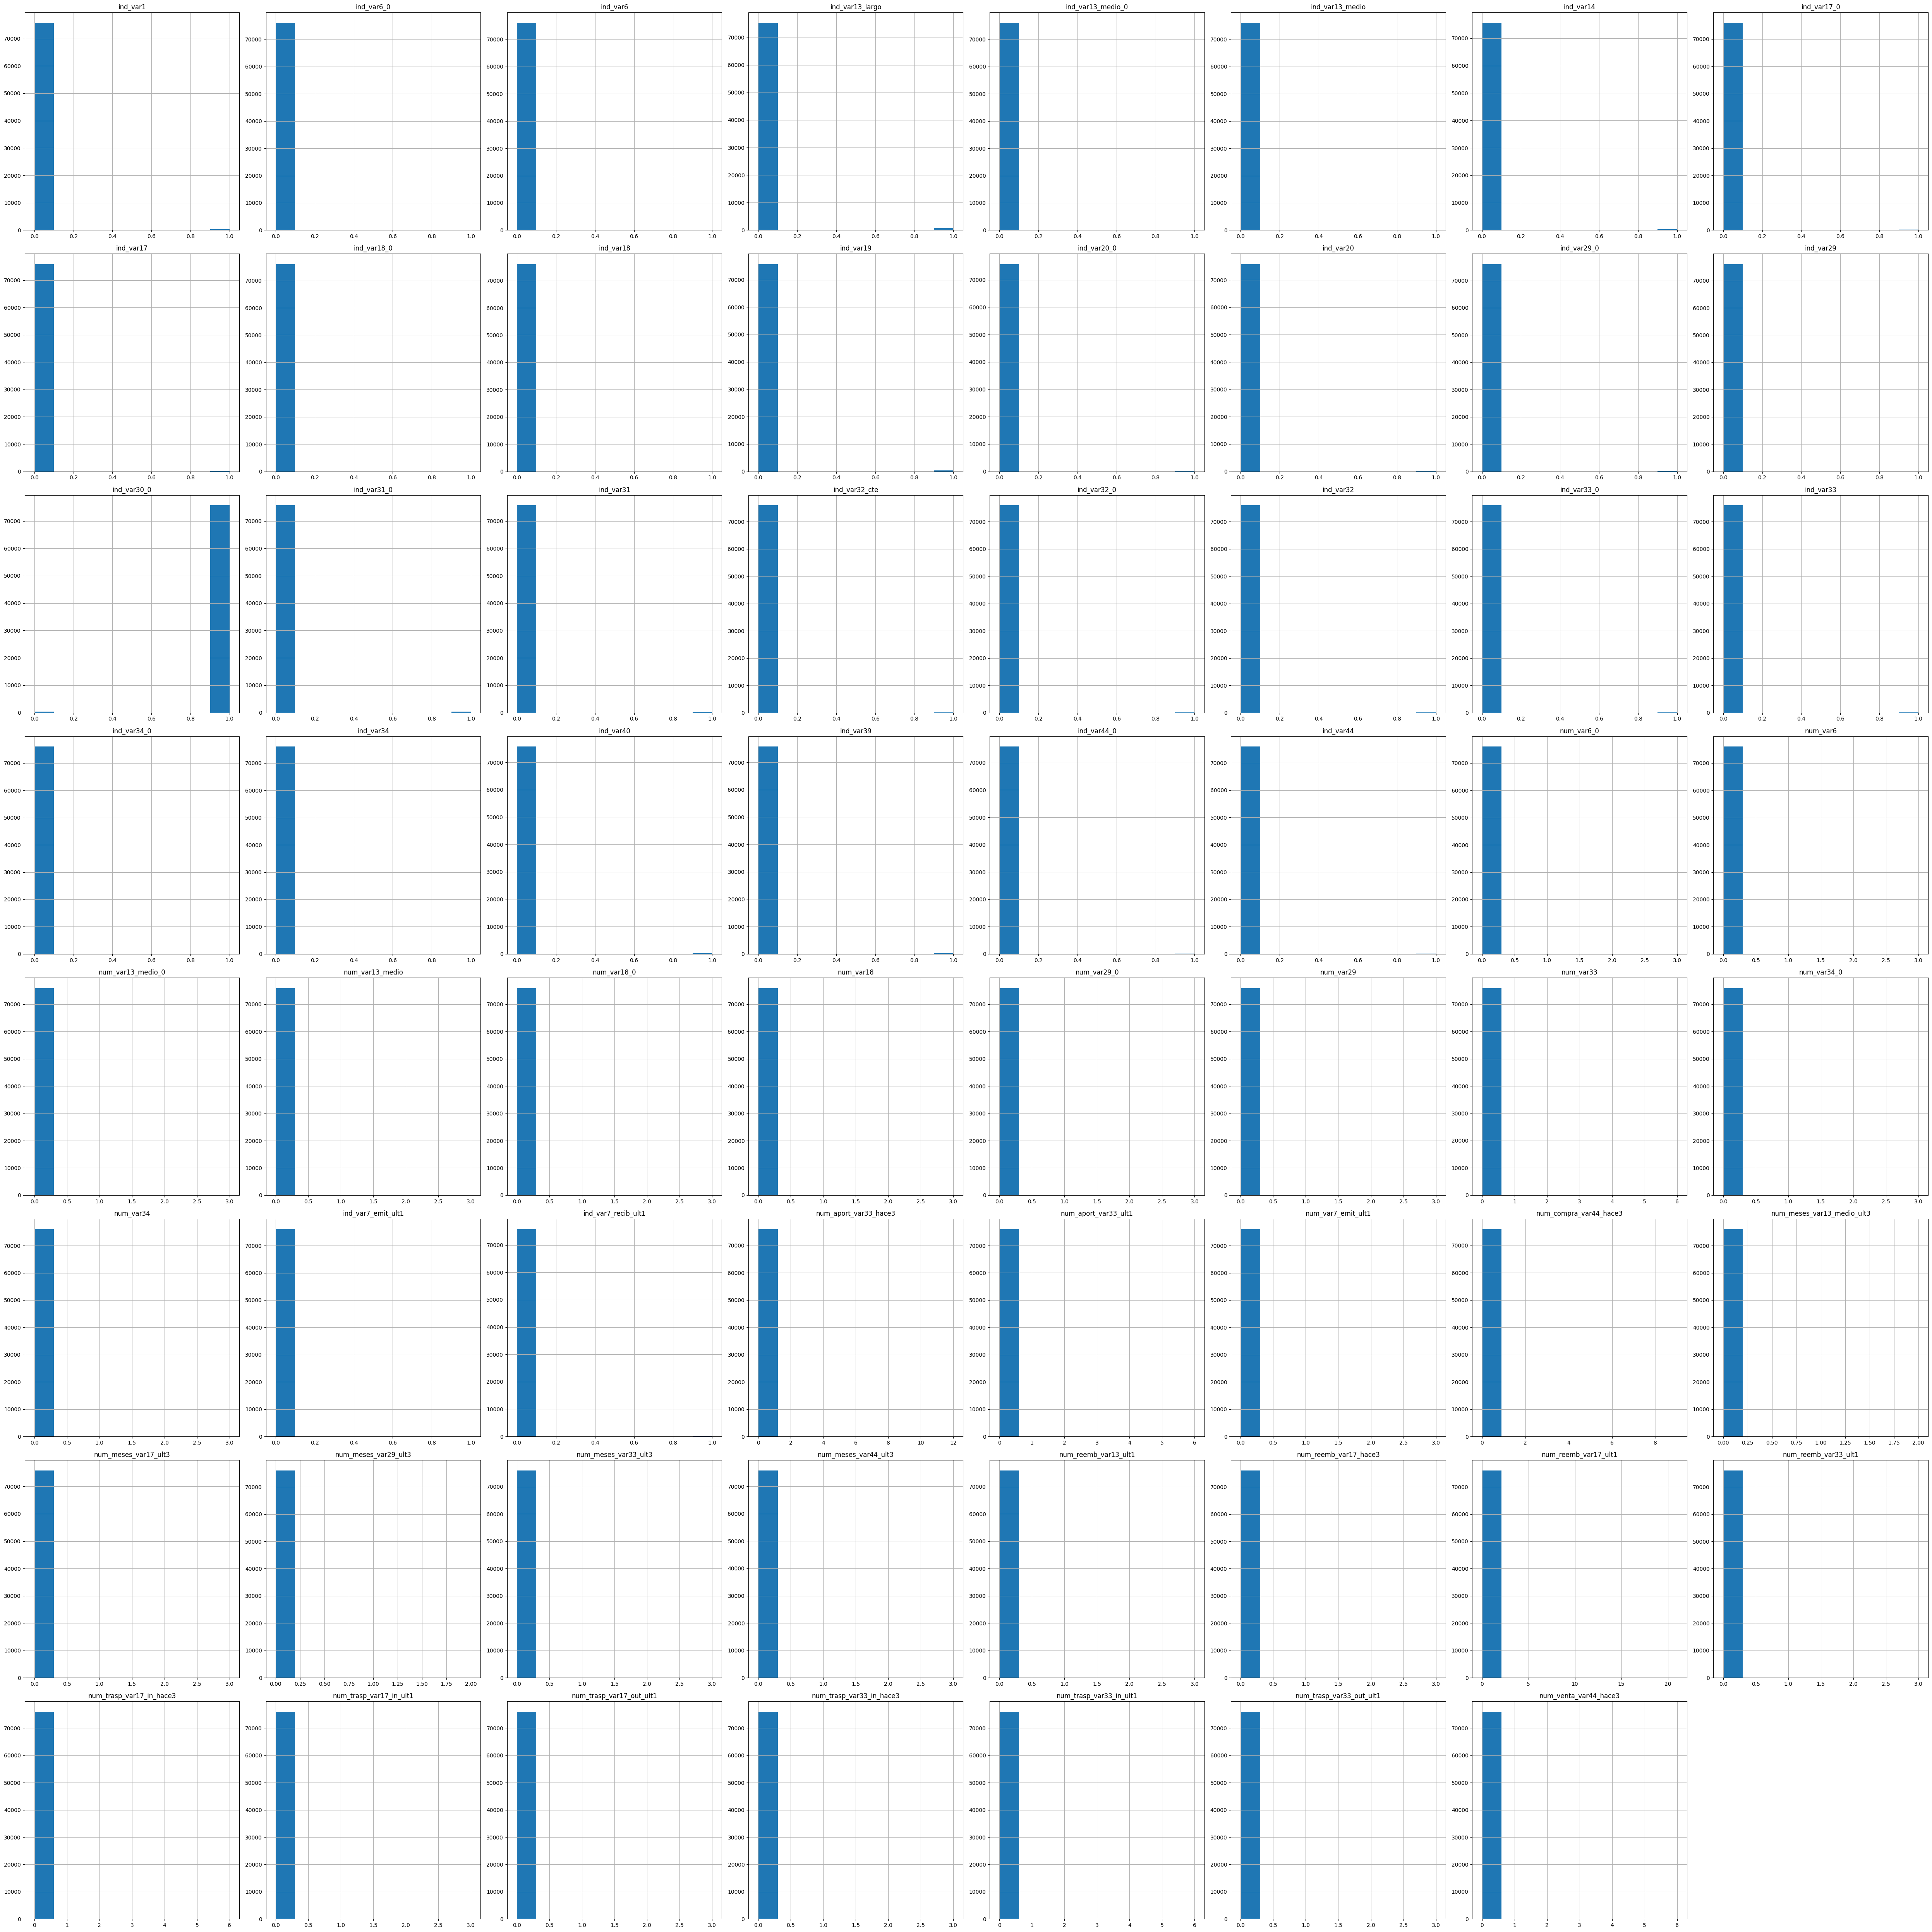

As we can see from the histograms above, these columns have very little variance and they have very little data in them. this is why we removed them from our dataset.


In [89]:
df[removed_cols].hist(figsize=(50, 50), bins=10)
plt.tight_layout()
plt.show()
print("As we can see from the histograms above, these columns have very little variance and they have very little data in them. this is why we removed them from our dataset.")

In [90]:
#lets drop the columns that were removed
df= df.drop(columns=removed_cols)

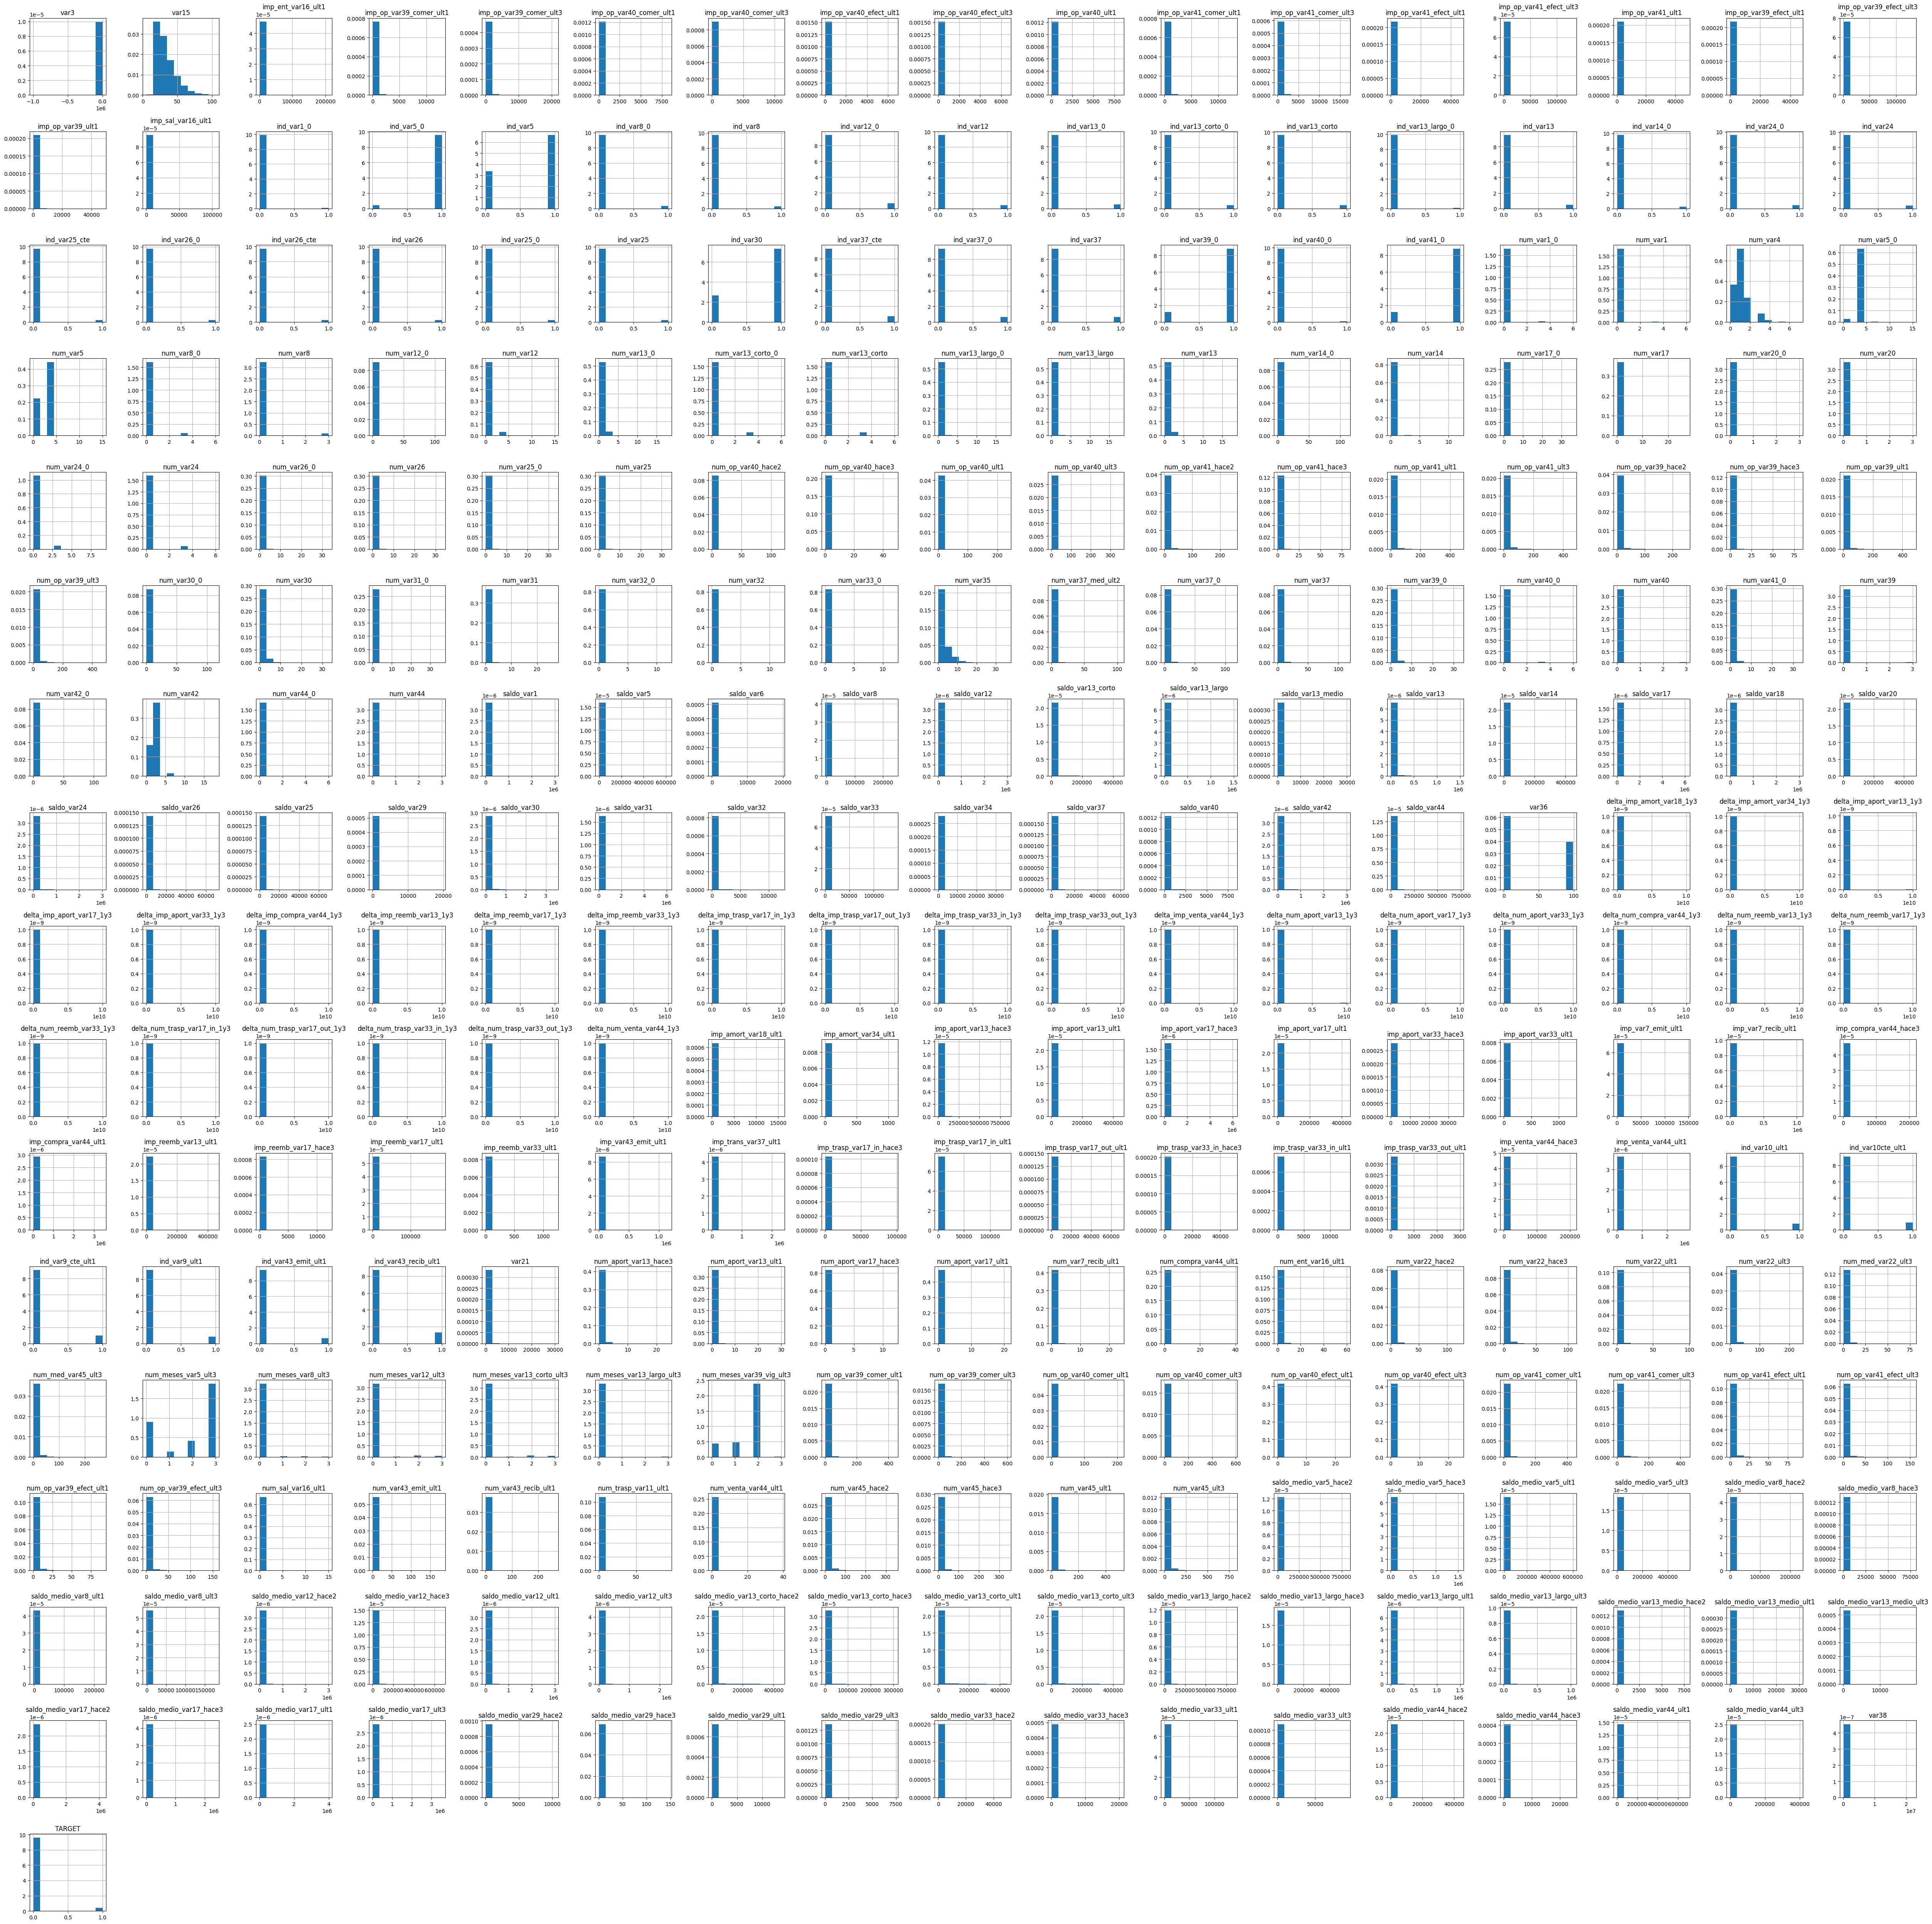

In [91]:
#now lets histogram the remining columns
df.hist(figsize=(50, 50), bins=10,density=True)
plt.tight_layout()
plt.show()

# Thoughts 
so the columns remaining are stilll sparse/ low-variance but we dont want to remove too many columns because we dont know what the data is and we dont want to remove any columns that might be important for our model. so we will just keep the columns that are left and we will see if we can find any patterns in the data by graphing the data and looking at the distribution of the data.

In [92]:
#now how many columns do we have left
print(len(df.columns))
#273 columns left

273


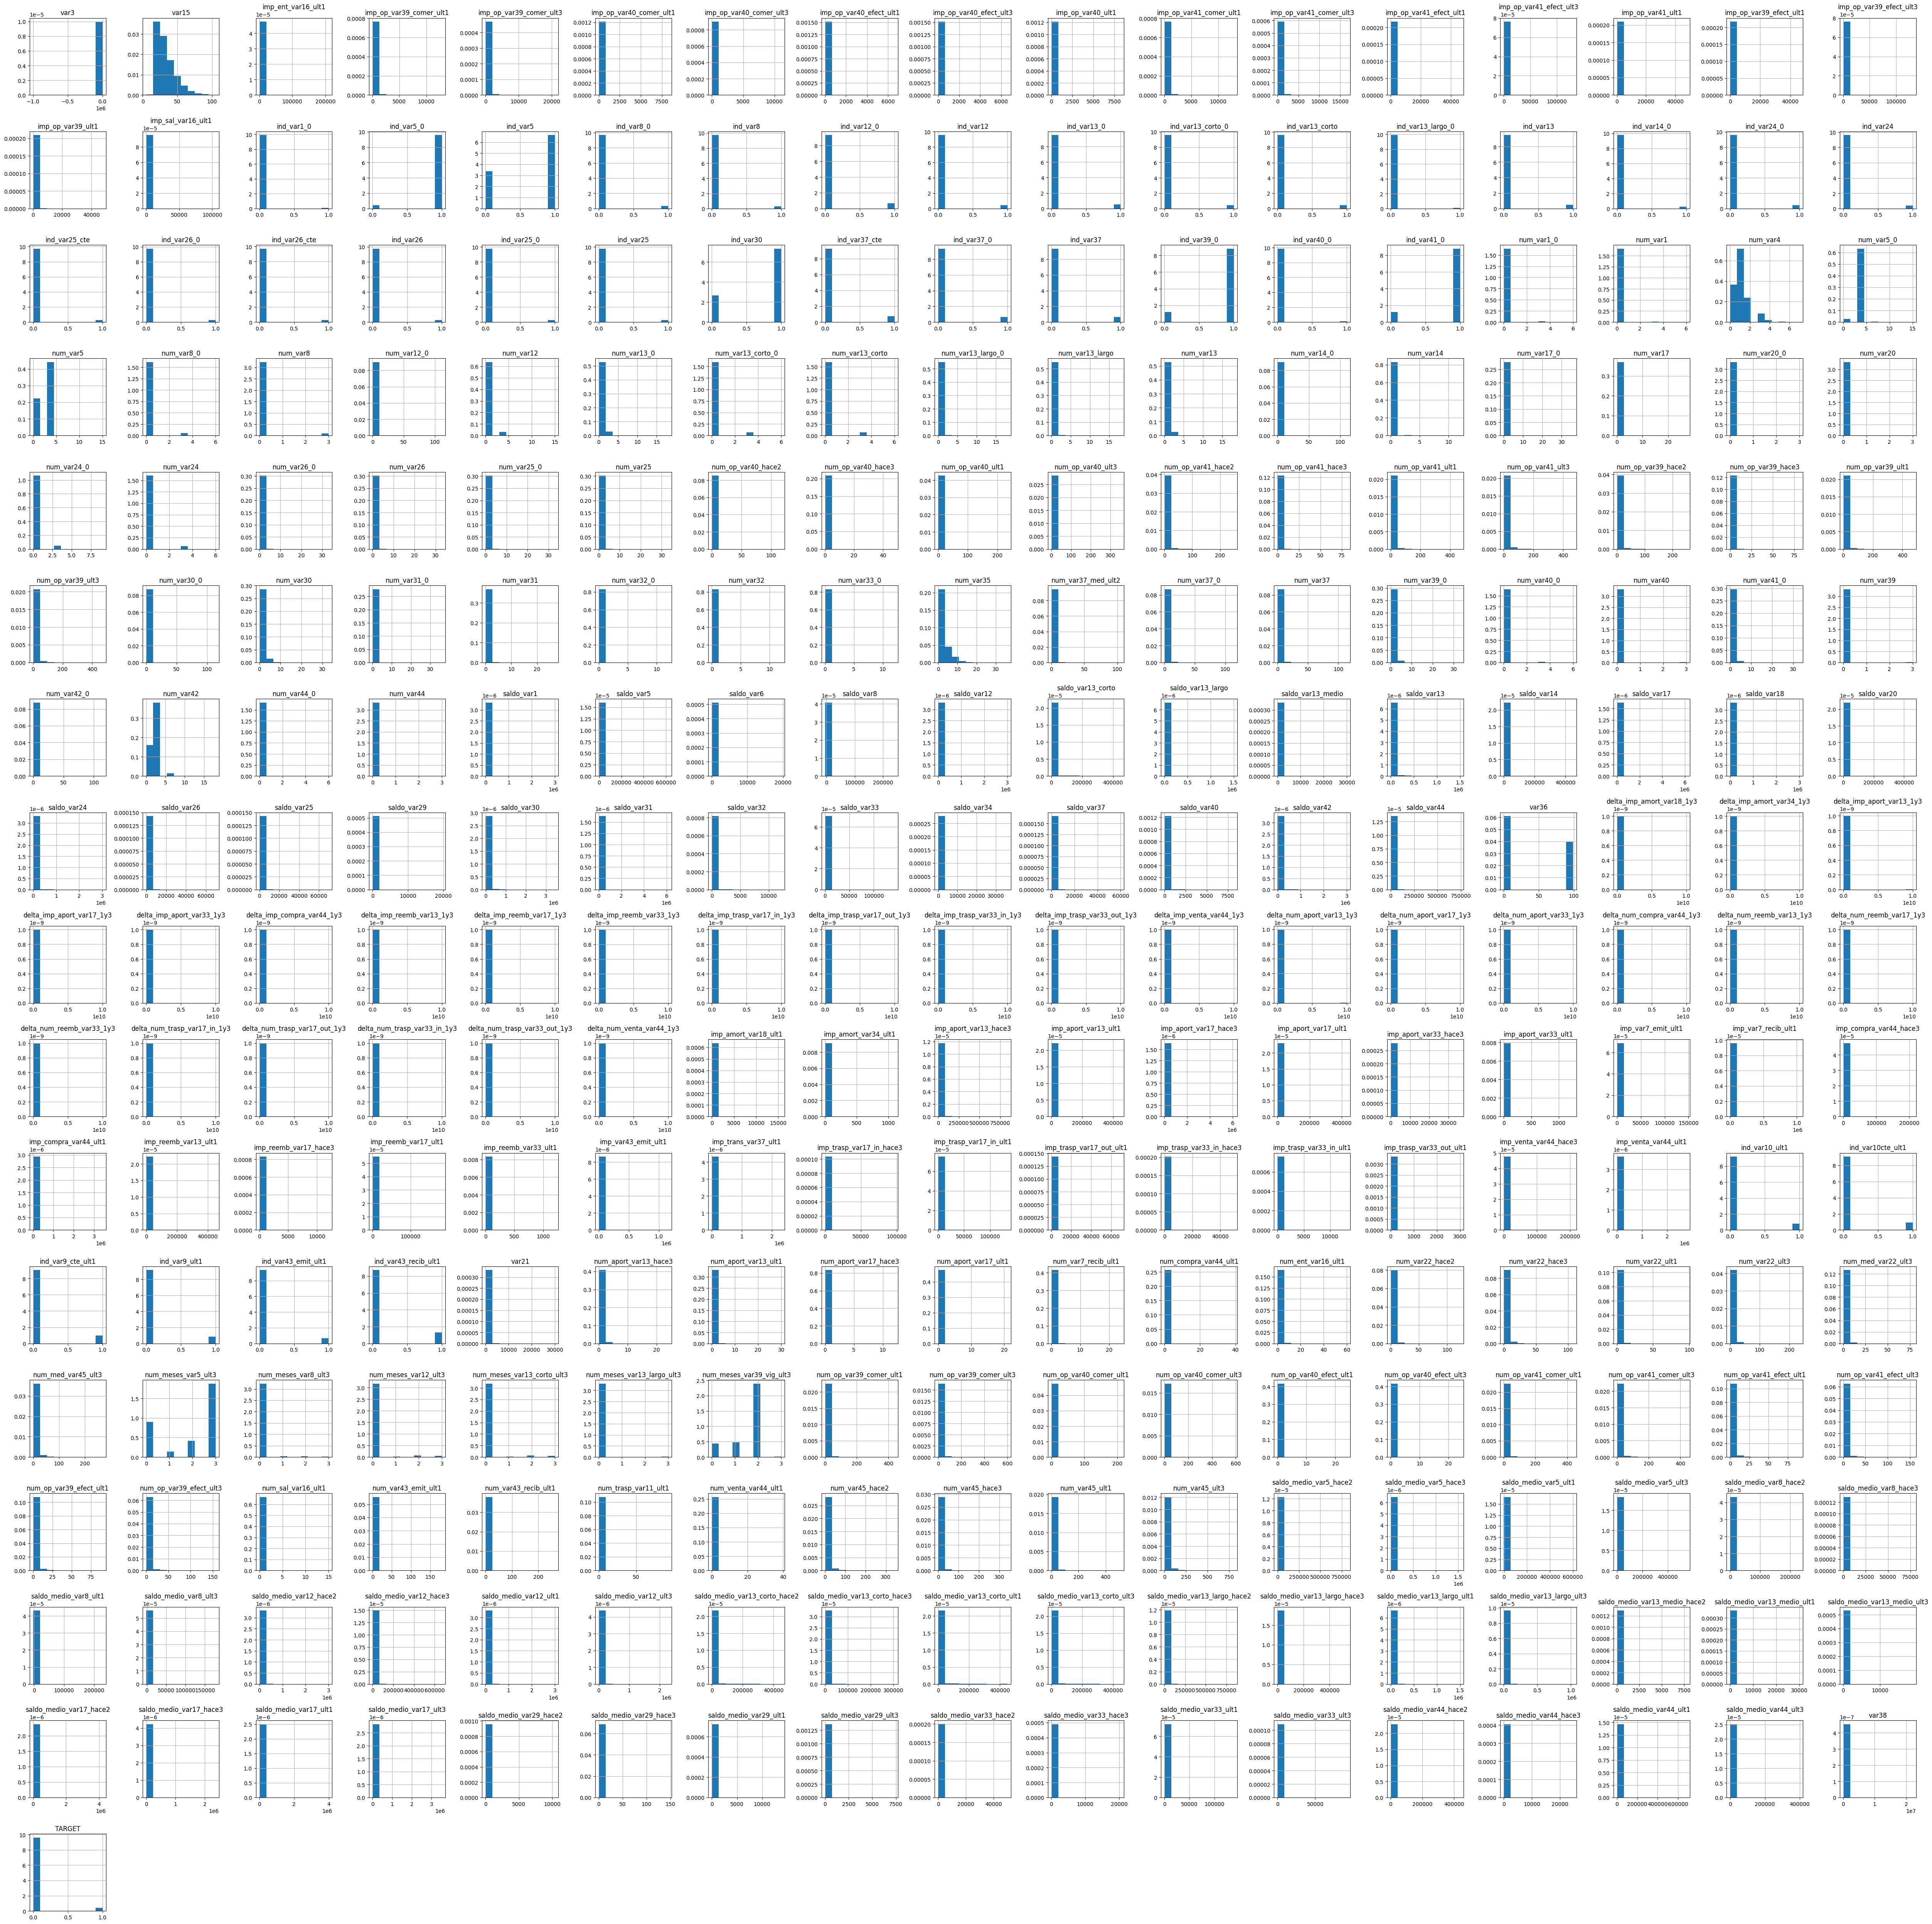

In [93]:
#lets graph the remaing features to see if there are any patterns in the data. we will do this in a 8x8 grid so we can see all the columns at once. we will also add a title to each graph so we know which column we are looking at.
df.hist(figsize=(50, 50), bins=10,density=True)
plt.tight_layout()
plt.show()


# Columns removed

So i used the variancethreshold method to remove about 60 columns with a variance of 0.1 which is approaching 0. now our data should consist of columns with actual data.

I believe that some columns are still mostly sparse but i dont want to remove valuable data. So what now?

Now, im going to use a randomforest model to determine the most important features that most correlate with the target variable. 

# Machine learning
Now that we have removed the sparse columns we can move forward with machine learning. we will use randomforestclassifier to classify our data and evaluate the model. We will also be looking at the top 30 most important variables reported

### 3.1 Train / Validation Split

Stratified 80/20 split — preserves the ~0.4% positive class ratio in both sets so the validation score isn't skewed by sampling luck.

In [94]:
#lets use a randomforest model to determine the most important features that most correlate with the target variable.

#split features and target
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

#stratified split keeps the ~4% positive rate balanced in both train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("train shape:", X_train.shape, "  val shape:", X_val.shape)
print("train positive rate:", round(y_train.mean(), 4))
print("val positive rate:  ", round(y_val.mean(), 4))

train shape: (60816, 272)   val shape: (15204, 272)
train positive rate: 0.0396
val positive rate:   0.0396


### 3.2 Baseline Model Training

Train a `RandomForestClassifier` on all remaining features.  
`class_weight='balanced'` compensates for the heavy class imbalance by up-weighting the minority class during training.  
ROC-AUC is used as the primary metric — plain accuracy is misleading when 99.6% of rows are class 0. 

In [95]:
#build and train the random forest
#class_weight='balanced' tells the model to pay extra attention to the rare positive class (~4% of rows)
#n_jobs=-1 uses all available CPU cores to train faster
#random_state=42 makes results reproducible
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
print("done training")

done training


In [96]:
#evaluate on the validation set
#with an imbalanced target, plain accuracy is misleading (predicting "0" for everyone gives ~96%).
#ROC-AUC measures ranking quality across all thresholds and is the right metric here.
from sklearn.metrics import roc_auc_score, classification_report

val_proba = rf.predict_proba(X_val)[:, 1]
val_pred  = rf.predict(X_val)

print("ROC-AUC on validation:", round(roc_auc_score(y_val, val_proba), 4))
print()
print(classification_report(y_val, val_pred, digits=4))

ROC-AUC on validation: 0.7588

              precision    recall  f1-score   support

           0     0.9638    0.9766    0.9702     14602
           1     0.1622    0.1096    0.1308       602

    accuracy                         0.9423     15204
   macro avg     0.5630    0.5431    0.5505     15204
weighted avg     0.9320    0.9423    0.9369     15204



### 3.3 Feature Importance & Model Pruning

Extract feature importances from the full model 


top 30 features by importance:
var38                       0.210347
var15                       0.194703
saldo_medio_var5_ult3       0.047943
saldo_medio_var5_hace3      0.043474
saldo_var30                 0.033267
saldo_medio_var5_ult1       0.025985
saldo_var42                 0.022926
saldo_medio_var5_hace2      0.021540
saldo_var5                  0.021280
num_var45_ult3              0.019891
num_var22_ult3              0.015174
num_var45_hace3             0.014927
num_meses_var5_ult3         0.013497
num_var45_hace2             0.012787
num_var30                   0.011418
var36                       0.010623
num_var45_ult1              0.010086
num_meses_var39_vig_ult3    0.009710
num_var22_hace2             0.009486
num_med_var45_ult3          0.009000
num_var22_hace3             0.008936
ind_var5                    0.008810
num_var35                   0.008697
ind_var30                   0.008634
num_var22_ult1              0.008147
num_var42                   0.006457
num_var

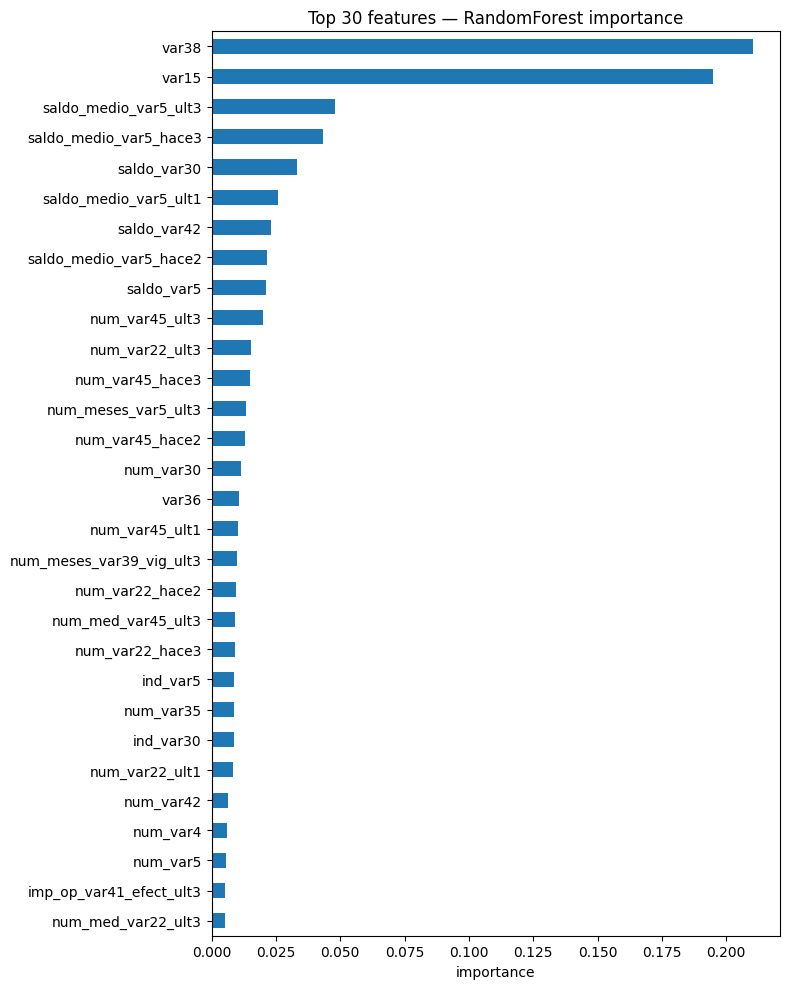

In [97]:
#now we look at which features did the model actually rely on?
#feature_importances_ is the average impurity reduction each feature gave across all 200 trees
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("top 30 features by importance:")
print(importances.head(30))

#plot the top 30
plt.figure(figsize=(8, 10))
importances.head(30).iloc[::-1].plot(kind="barh")
plt.title("Top 30 features — RandomForest importance")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

In [98]:
#pick the cutoff: how many features do we need to cover 95% of total importance?
#importances already sum to 1.0, so a cumulative sum tells us the running total as we add features in order
cum = importances.cumsum()

for pct in [0.80, 0.90, 0.95, 0.99]:
    n = (cum <= pct).sum() + 1
    print(f"features needed to reach {int(pct*100)}% of importance: {n}")

#lets go with 95% as our cutoff and drop the tail
top_features = importances[cum <= 0.95].index.tolist()
#include the feature that pushes us past 0.95 too, so we actually cover it
if len(top_features) < len(importances):
    top_features.append(importances.index[len(top_features)])

print(f"\nkeeping {len(top_features)} features, dropping {len(importances) - len(top_features)} from the tail")

features needed to reach 80% of importance: 25
features needed to reach 90% of importance: 51
features needed to reach 95% of importance: 76
features needed to reach 99% of importance: 125

keeping 76 features, dropping 196 from the tail


In [99]:
#retrain the same RandomForest on the pruned feature set
#same hyperparameters as before so the comparison is apples-to-apples
X_train_top = X_train[top_features]
X_val_top   = X_val[top_features]

rf_pruned = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf_pruned.fit(X_train_top, y_train)
print("done training pruned model on", len(top_features), "features")

done training pruned model on 76 features


In [100]:
#compare pruned vs full-feature model on the same validation set
val_proba_pruned = rf_pruned.predict_proba(X_val_top)[:, 1]
val_pred_pruned  = rf_pruned.predict(X_val_top)

auc_full   = roc_auc_score(y_val, val_proba)
auc_pruned = roc_auc_score(y_val, val_proba_pruned)

print(f"full model    ({X_train.shape[1]} features): ROC-AUC = {auc_full:.4f}")
print(f"pruned model  ({len(top_features)} features): ROC-AUC = {auc_pruned:.4f}")
print(f"difference: {auc_pruned - auc_full:+.4f}")
print()
print("classification report (pruned model):")
print(classification_report(y_val, val_pred_pruned, digits=4))

full model    (272 features): ROC-AUC = 0.7588
pruned model  (76 features): ROC-AUC = 0.7647
difference: +0.0058

classification report (pruned model):
              precision    recall  f1-score   support

           0     0.9642    0.9760    0.9701     14602
           1     0.1726    0.1213    0.1424       602

    accuracy                         0.9422     15204
   macro avg     0.5684    0.5486    0.5563     15204
weighted avg     0.9329    0.9422    0.9373     15204



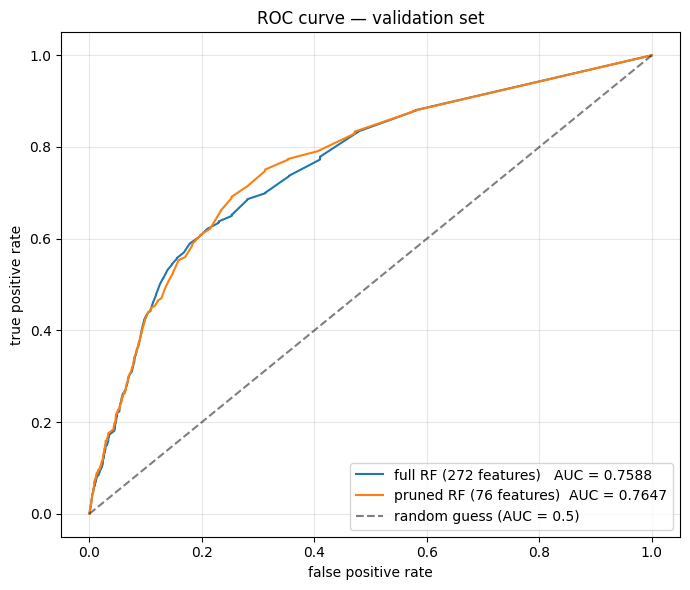

In [102]:
#ROC curve - visualizes how well the model ranks positives above negatives across all thresholds
#x-axis = false positive rate, y-axis = true positive rate. higher curve = better model.
#the dashed diagonal is random guessing (AUC = 0.5); the further the curve bows toward the top-left, the better
from sklearn.metrics import roc_curve

fpr_full,   tpr_full,   _ = roc_curve(y_val, val_proba)
fpr_pruned, tpr_pruned, _ = roc_curve(y_val, val_proba_pruned)

plt.figure(figsize=(7, 6))
plt.plot(fpr_full,   tpr_full,   label=f"full RF (272 features)   AUC = {auc_full:.4f}")
plt.plot(fpr_pruned, tpr_pruned, label=f"pruned RF (76 features)  AUC = {auc_pruned:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="random guess (AUC = 0.5)")

plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve — validation set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# What the ROC curve tells us 
The model is doing good we have a good TPR with an acceptable FPR with the pruned model performing slightly better, as we saw earlier.  The ROC curve is a great way to visualize the performance of a binary classifier across all classification thresholds. The pruned model's curve being above the full model's curve indicates that it has better discriminative ability, likely due to reduced overfitting and noise from less important features.

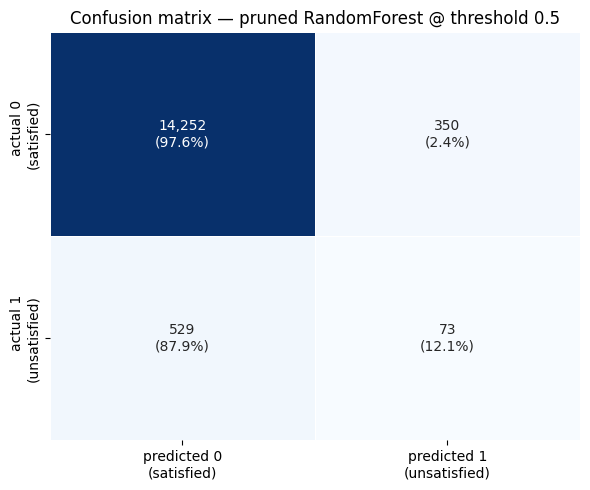

In [103]:
#confusion matrix - shows where the pruned model gets it right vs wrong at the default 0.5 threshold
#rows = actual class, columns = predicted class
#each cell is annotated with both the raw count and the % of that actual class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_pred_pruned)

#row-normalize so we can see "what fraction of each actual class did the model classify which way"
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

#build text labels showing both count and percent
labels = np.array([
    [f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["predicted 0\n(satisfied)", "predicted 1\n(unsatisfied)"],
    yticklabels=["actual 0\n(satisfied)",    "actual 1\n(unsatisfied)"],
    linewidths=0.5,
    linecolor="white",
)
plt.title("Confusion matrix — pruned RandomForest @ threshold 0.5")
plt.tight_layout()
plt.show()

# Thoughts on the Confusion Matrix

The **top row** looks great — of the actual satisfied customers, the model gets **97.6%** correctly classified and only falsely flags **2.4%**. That part of the model works well.

The **bottom row** is where it falls apart. Of the actual unsatisfied customers, the model only catches **12.1%** (73 out of 602) and misses the other ~88%. This is the **imbalance trap**: by playing it safe and predicting "satisfied" for almost everyone, the model lands a fake-looking 94% accuracy but fails at the real goal — identifying unsatisfied customers.

This is exactly why we trust **ROC-AUC (0.76)** as our headline metric, not accuracy (0.94). ROC-AUC measures how well the model *ranks* customers by risk, not how often it agrees with the easy majority class. And it's why we used the ROC curve's derivative to pick a much lower threshold (~0.034) — at the default 0.5, almost no one clears the bar.

In [101]:
import joblib

joblib.dump(rf_pruned, "rf_pruned.joblib")

preprocessing_state = {
    "zero_cols":    list(zero_cols),
    "low_var_cols": list(removed_cols),
    "top_features": list(top_features),
}
joblib.dump(preprocessing_state, "preprocessing_state.joblib")

print("saved rf_pruned.joblib and preprocessing_state.joblib")

saved rf_pruned.joblib and preprocessing_state.joblib


## Summary & Next Steps

### What was done
| Step | Action | Columns remaining |
|---|---|---|
| Raw data | Load `train.csv` | 374 |
| Drop ID | Remove non-predictive column | 373 |
| Drop all-zero columns | Remove 34 fully-empty columns | ~336 |
| VarianceThreshold (0.01) | Remove near-zero-variance features | ~273 |
| RF importance cutoff (95%) | Drop low-importance tail | top-N |

### Key findings
- The dataset is **heavily imbalanced** (~0.4% positive class) — ROC-AUC is the right metric, not accuracy
- Most features have **very weak individual correlation** with the target (max ~0.10), suggesting the signal is distributed and non-linear
- A `RandomForestClassifier` with `class_weight='balanced'` handles the imbalance well out of the box
- Pruning to the 95% importance cutoff retains nearly all predictive power with fewer features

### Next steps
- Apply the same preprocessing pipeline to `test.csv` using the saved `preprocessing_state.joblib`
- Generate predictions with the saved `rf_pruned.joblib` model
- Submit predictions to Kaggle